# TimeSeriesExam1 — Dataset Inspection & Evaluation Demo

This notebook shows:
1. What a **`Sample`** from `TimeSeriesExam1Dataset` looks like in both the
   **canonical (separate)** form and the **combined** form an LLM sees.
2. How to **run an evaluation** with the `LocalEvaluationPipeline`.
3. How to **read the results**: aggregate metrics, per-sample predictions,
   and breakdowns by difficulty / category / number of options.


## 1 — Setup

In [1]:
import sys, pathlib
# Make sure the project root is on the path when the notebook runs from notebooks/
_root = pathlib.Path().resolve().parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", "{:.4f}".format)

from fmeval.core.datasets.tsexam1 import TimeSeriesExam1Dataset
from fmeval.core.datasets.formatters import SampleFormatter
from fmeval.core.models.mock_model import MockModel
from fmeval.core.metrics.mcq_metrics import MCQMetrics
from fmeval.evaluation.pipeline import LocalEvaluationPipeline

print("All imports OK.")


All imports OK.


---
## Part 1 — What a Sample Looks Like

We load a small slice of the dataset and inspect each field of the `Sample` dataclass.


In [2]:
# Load 10 samples — enough to guarantee both 1-TS and 2-TS rows appear
ds = TimeSeriesExam1Dataset(max_samples=10)
samples = list(ds)

one_ts_sample = next(s for s in samples if len(s.input_ts) == 1)
two_ts_sample  = next(s for s in samples if len(s.input_ts) == 2)

print(f"Total samples loaded : {len(samples)}")
print(f"1-TS samples          : {sum(len(s.input_ts) == 1 for s in samples)}")
print(f"2-TS samples          : {sum(len(s.input_ts) == 2 for s in samples)}")


Total samples loaded : 10
1-TS samples          : 3
2-TS samples          : 7


### 1.1 — `input_text` (canonical / separate form)

`<TS_0>` is a placeholder — the raw numpy array lives in `input_ts[0]`.
This is what a model with a **dedicated TS encoder** receives as-is.


In [3]:
print(one_ts_sample.input_text)


Time series: <TS_0>

Question: The given time series has sine wave pattern. How does its amplitude change from the beginning to the end?

Options:
A) Increase
B) Remain the same
C) Decrease

Please answer the question and provide the correct option letter, e.g., A), B), C), D), and option content at the end of your answer. All information need to answer the question is given. If you are unsure, please provide your best guess.


### 1.2 — `input_ts` (raw time-series arrays)

In [4]:
ts = one_ts_sample.input_ts[0]
print(f"  number of arrays : {len(one_ts_sample.input_ts)}")
print(f"  dtype            : {ts.dtype}")
print(f"  shape            : {ts.shape}")
print(f"  min / mean / max : {ts.min():.3f} / {ts.mean():.3f} / {ts.max():.3f}")
print(f"  first 12 values  : {ts[:12].tolist()}")


  number of arrays : 1
  dtype            : float32
  shape            : (1024,)
  min / mean / max : -11.016 / -3.957 / 8.228
  first 12 values  : [0.037208620458841324, 2.2235636711120605, 4.467204570770264, 6.2487969398498535, 7.529087543487549, 7.83184289932251, 7.846982002258301, 7.20371150970459, 6.002788066864014, 4.031768321990967, 1.672899603843689, -0.5862748026847839]


### 1.3 — Visualising the time series

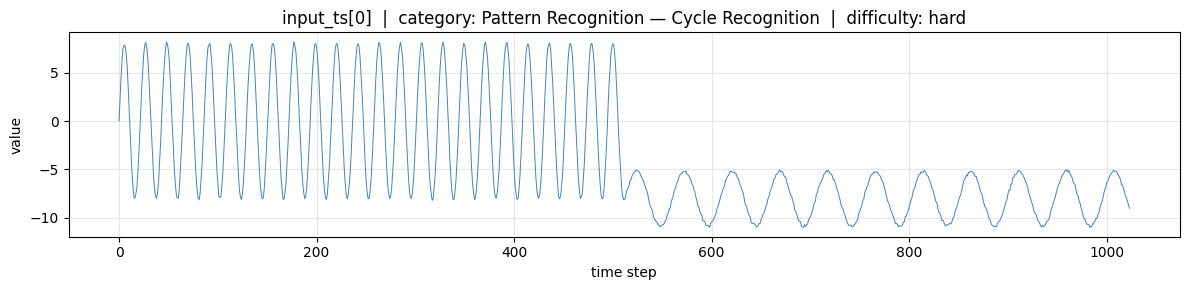

In [5]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(one_ts_sample.input_ts[0], lw=0.7, color="steelblue")
ax.set_title(
    f"input_ts[0]  |  category: {one_ts_sample.metadata['category']} "
    f"— {one_ts_sample.metadata['subcategory']}  |  difficulty: {one_ts_sample.metadata['difficulty']}"
)
ax.set_xlabel("time step")
ax.set_ylabel("value")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 1.4 — `output` and `metadata`

In [6]:
print("output (ground-truth answer):")
print(" ", repr(one_ts_sample.output))
print()
print("metadata:")
for k, v in one_ts_sample.metadata.items():
    print(f"  {k:<22} {v}")


output (ground-truth answer):
  'C) Decrease'

metadata:
  id                     2
  tid                    17
  question_type          multiple-choice
  difficulty             hard
  category               Pattern Recognition
  subcategory            Cycle Recognition
  relevant_concepts      ['Sine Wave', 'Amplitude']
  answer_letter          C
  answer_text            Decrease
  num_options            3


### 1.5 — Combined form (what an LLM sees)

`SampleFormatter.to_combined()` replaces every `<TS_N>` token with the serialised
float values. This is what a standard LLM receives — **a single text string** with
the time series inline.


In [7]:
combined = SampleFormatter.to_combined(one_ts_sample)

print("=== combined.input_text (first 600 chars) ===")
print(combined.input_text[:600])
print("  ... (truncated)")
print()
print(f"combined.input_ts : {combined.input_ts}  ← empty; TS is now inside the text")


=== combined.input_text (first 600 chars) ===
Time series: [0.03721, 2.224, 4.467, 6.249, 7.529, 7.832, 7.847, 7.204, 6.003, 4.032, 1.673, -0.5863, -2.894, -5.109, -6.637, -7.86, -8.015, -7.533, -6.947, -5.433, -3.478, -1.292, 1.269, 3.551, 5.276, 6.931, 7.877, 8.137, 7.715, 6.604, 4.956, 2.85, 0.6036, -1.621, -3.778, -5.896, -7.084, -7.827, -7.996, -7.429, -6.305, -4.348, -2.399, 0.08811, 2.414, 4.347, 6.206, 7.365, 8.195, 7.958, 7.295, 5.966, 3.91, 1.595, -0.7456, -2.726, -5.034, -6.563, -7.58, -7.988, -7.969, -7.029, -5.203, -3.263, -1.051, 1.356, 3.323, 5.329, 6.841, 7.867, 8.075, 7.714, 6.64, 4.925, 2.935, 0.3936, -1.68, -3.866, -5.8
  ... (truncated)

combined.input_ts : []  ← empty; TS is now inside the text


### 1.6 — Sample with two time series

Some questions compare two series. Both placeholders appear in `input_text`;
both arrays are in `input_ts`.


In [8]:
print("input_text:")
print(two_ts_sample.input_text)
print()
print(f"len(input_ts) = {len(two_ts_sample.input_ts)}")
print(f"input_ts[0].shape = {two_ts_sample.input_ts[0].shape}")
print(f"input_ts[1].shape = {two_ts_sample.input_ts[1].shape}")


input_text:
Time series 1: <TS_0>
Time series 2: <TS_1>

Question: Are the given two time series likely to have the same underlying distribution?

Options:
A) No, they have different underlying distribution
B) Yes, they have the same underlying distribution: Gaussian White Noise

Please answer the question and provide the correct option letter, e.g., A), B), C), D), and option content at the end of your answer. All information need to answer the question is given. If you are unsure, please provide your best guess.

len(input_ts) = 2
input_ts[0].shape = (1024,)
input_ts[1].shape = (1024,)


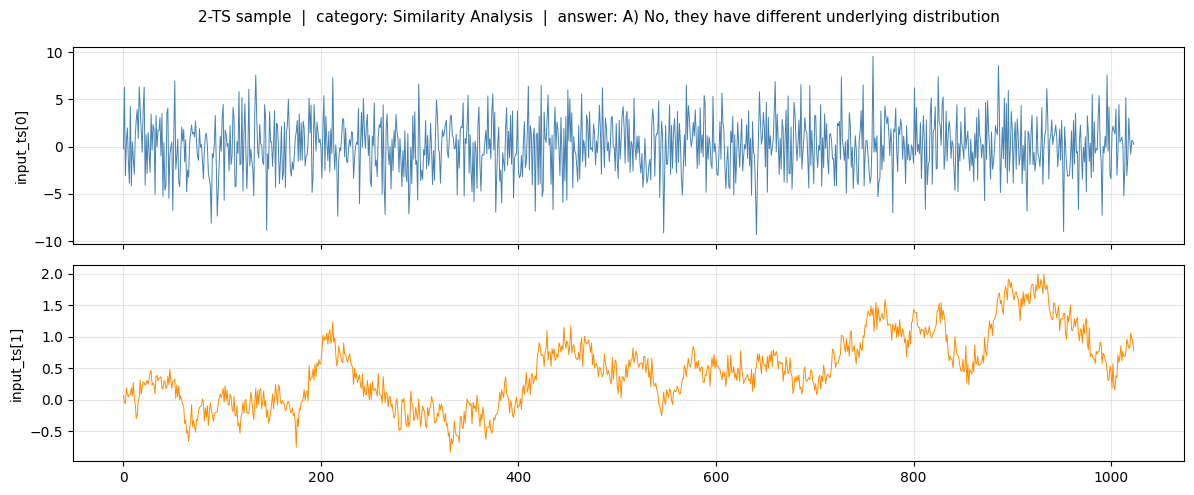

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
colors = ["steelblue", "darkorange"]
for i, ax in enumerate(axes):
    ax.plot(two_ts_sample.input_ts[i], lw=0.7, color=colors[i])
    ax.set_ylabel(f"input_ts[{i}]")
    ax.grid(True, alpha=0.3)
fig.suptitle(
    f"2-TS sample  |  category: {two_ts_sample.metadata['category']}  "
    f"|  answer: {two_ts_sample.output}",
    fontsize=11,
)
plt.tight_layout()
plt.show()


---
## Part 2 — Running the Evaluation Pipeline

```
TimeSeriesExam1Dataset
        │  yields Sample objects (separate form)
        ▼
LocalEvaluationPipeline
    ├─ model.format_input(sample)  →  calls SampleFormatter.to_combined (MockModel)
    ├─ model.predict(batch)        →  returns list[str]   ("A)" for every input)
    └─ MCQMetrics.compute(preds, targets)
        │
        ▼
RunResult  (metrics + per-sample SamplePrediction list)
```

The **`MockModel`** always answers `"A)"` — it is the simplest possible baseline
and lets us verify the full pipeline is wired correctly before plugging in a real model.


In [9]:
# Load 200 samples to get a meaningful metric distribution
ds_eval = TimeSeriesExam1Dataset(max_samples=200)

model    = MockModel(answer="A")
metric   = MCQMetrics()
pipeline = LocalEvaluationPipeline(model, metric, batch_size=32, verbose=False)

result = pipeline.run(ds_eval)
print(f"Run complete — {result.num_samples} samples evaluated.")
print(f"run_config: {result.run_config}")


Run complete — 200 samples evaluated.
run_config: {'model_name': 'mock_always_A', 'dataset_name': 'tsexam1', 'input_mode': 'combined', 'batch_size': 32, 'metric': 'mcq_metrics', 'timestamp': '2026-06-08T12:05:49.287241'}


---
## Part 3 — Reading the Results


### 3.1 — Text summary

In [10]:
print(result.summary())


Model:    mock_always_A
Dataset:  tsexam1
Samples:  200
Time:     2026-06-08 12:05:49

── Aggregate metrics ─────────────────────────
  accuracy                   0.4300
  balanced_accuracy          0.3333
  f1_macro                   0.2005
  f1_weighted                0.2586
  precision_macro            0.1433
  precision_weighted         0.1849
  recall_macro               0.3333
  recall_weighted            0.4300
  n_samples                  200.0000
  n_unparseable              0.0000

── Per-class breakdown ───────────────────────
  A  support=  86  f1=0.601  prec=0.430  rec=1.000
  B  support=  76  f1=0.000  prec=0.000  rec=0.000
  C  support=  38  f1=0.000  prec=0.000  rec=0.000


### 3.2 — Per-sample DataFrame

`result.to_dataframe()` produces one row per sample. All `Sample.metadata`
fields (difficulty, category, etc.) are promoted to top-level columns so you
can filter and slice freely.


In [11]:
df = result.to_dataframe()
print(f"Shape: {df.shape}  columns: {list(df.columns)}")
df[["sample_idx", "predicted_letter", "correct_letter", "is_correct",
    "difficulty", "category", "num_options"]].head(12)


Shape: (200, 16)  columns: ['sample_idx', 'raw_prediction', 'raw_target', 'predicted_letter', 'correct_letter', 'is_correct', 'id', 'tid', 'question_type', 'difficulty', 'category', 'subcategory', 'relevant_concepts', 'answer_letter', 'answer_text', 'num_options']


,sample_idx,predicted_letter,correct_letter,is_correct,difficulty,category,num_options
0,0,A,A,True,hard,Similarity Analysis,2
1,1,A,C,False,hard,Pattern Recognition,3
2,2,A,A,True,easy,Similarity Analysis,2
3,3,A,A,True,easy,Similarity Analysis,2
4,4,A,A,True,hard,Similarity Analysis,2
5,5,A,A,True,hard,Pattern Recognition,2
6,6,A,B,False,hard,Similarity Analysis,2
7,7,A,B,False,hard,Causality Analysis,3
8,8,A,A,True,easy,Causality Analysis,3
9,9,A,A,True,easy,Pattern Recognition,3


### 3.3 — Breakdown by difficulty

In [12]:
bd_difficulty = result.breakdown_by("difficulty")
display(bd_difficulty)


,difficulty,n_samples,n_correct,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,n_unparseable
0,easy,58,30,0.5172,0.3333,0.2273,0.1724,0.3333,0
1,hard,132,52,0.3939,0.3333,0.1884,0.1313,0.3333,0
2,medium,10,4,0.4000,0.3333,0.1905,0.1333,0.3333,0


### 3.4 — Breakdown by category

In [13]:
bd_category = result.breakdown_by("category").sort_values("accuracy", ascending=False)
display(bd_category)


,category,n_samples,n_correct,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,n_unparseable
4,Similarity Analysis,29,15,0.5172,0.3333,0.2273,0.1724,0.3333,0
3,Pattern Recognition,101,47,0.4653,0.3333,0.2117,0.1551,0.3333,0
2,Noise Understanding,22,10,0.4545,0.3333,0.2083,0.1515,0.3333,0
1,Causality Analysis,16,6,0.3750,0.3333,0.1818,0.1250,0.3333,0
0,Anolmaly Detection,32,8,0.2500,0.3333,0.1333,0.0833,0.3333,0


### 3.5 — Breakdown by number of options

In [15]:
bd_options = result.breakdown_by("num_options")
display(bd_options)


,num_options,n_samples,n_correct,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,n_unparseable
0,2,84,49,0.5833,0.5000,0.3684,0.2917,0.5000,0
1,3,114,36,0.3158,0.3333,0.1600,0.1053,0.3333,0
2,4,2,1,0.5000,0.5000,0.3333,0.2500,0.5000,0


### 3.6 — Charts

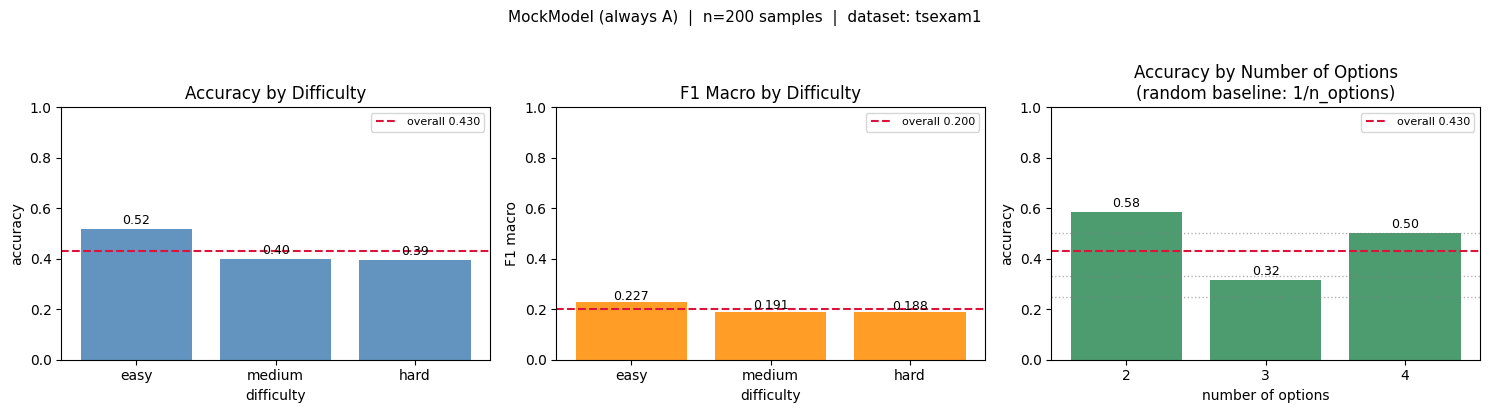

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Accuracy by difficulty ──────────────────────────────────────────────────
ax = axes[0]
bd_d = bd_difficulty.sort_values("accuracy", ascending=False)
bars = ax.bar(bd_d["difficulty"], bd_d["accuracy"], color="steelblue", alpha=0.85)
ax.axhline(result.metrics["accuracy"], color="crimson", ls="--", lw=1.5, label=f"overall {result.metrics['accuracy']:.3f}")
ax.set_ylim(0, 1)
ax.set_xlabel("difficulty")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy by Difficulty")
ax.legend(fontsize=8)
for bar, val in zip(bars, bd_d["accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.2f}", ha="center", fontsize=9)

# ── F1 macro by difficulty ──────────────────────────────────────────────────
ax = axes[1]
bars = ax.bar(bd_d["difficulty"], bd_d["f1_macro"], color="darkorange", alpha=0.85)
ax.axhline(result.metrics["f1_macro"], color="crimson", ls="--", lw=1.5, label=f"overall {result.metrics['f1_macro']:.3f}")
ax.set_ylim(0, 1)
ax.set_xlabel("difficulty")
ax.set_ylabel("F1 macro")
ax.set_title("F1 Macro by Difficulty")
ax.legend(fontsize=8)
for bar, val in zip(bars, bd_d["f1_macro"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.3f}", ha="center", fontsize=9)

# ── Accuracy by num_options ─────────────────────────────────────────────────
ax = axes[2]
bd_o = bd_options.sort_values("num_options")
x_labels = [str(v) for v in bd_o["num_options"]]
bars = ax.bar(x_labels, bd_o["accuracy"], color="seagreen", alpha=0.85)
ax.axhline(result.metrics["accuracy"], color="crimson", ls="--", lw=1.5, label=f"overall {result.metrics['accuracy']:.3f}")
ax.set_ylim(0, 1)
ax.set_xlabel("number of options")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy by Number of Options\n(random baseline: 1/n_options)")
for n_opts, bar, val in zip(bd_o["num_options"], bars, bd_o["accuracy"]):
    baseline = 1 / n_opts
    ax.axhline(baseline, color="gray", ls=":", lw=1, alpha=0.6)
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.2f}", ha="center", fontsize=9)
ax.legend(fontsize=8)

plt.suptitle(
    f"MockModel (always A)  |  n={result.num_samples} samples  |  dataset: tsexam1",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()


### 3.7 — Export to JSON / CSV

In [17]:
import json, pathlib

out_dir = pathlib.Path("results")
out_dir.mkdir(exist_ok=True)

# JSON — full result with every sample prediction
json_path = out_dir / "mock_tsexam1.json"
json_path.write_text(result.to_json())
print(f"Saved: {json_path}  ({json_path.stat().st_size // 1024} KB)")

# CSV — flat per-sample table
csv_path = out_dir / "mock_tsexam1_samples.csv"
result.to_dataframe().to_csv(csv_path, index=False)
print(f"Saved: {csv_path}  ({csv_path.stat().st_size // 1024} KB)")

# Preview the JSON structure
print("\nJSON top-level keys:", list(json.loads(json_path.read_text()).keys()))


Saved: results/mock_tsexam1.json  (126 KB)
Saved: results/mock_tsexam1_samples.csv  (35 KB)

JSON top-level keys: ['model_name', 'dataset_name', 'timestamp', 'num_samples', 'metrics', 'run_config', 'sample_predictions']
